# Finite-Strain-Kontakt in 3D: zweischichtiger Halbring auf elastischem Block

Dieses Beispiel extrudiert die Geometrie aus `contact_finite_strain.ipynb`
über eine endliche Breite von **20 mm**. Radien, Schichtdicken, Materialien,
Blockabmessungen und Endverschiebung entsprechen dem 2D-Beispiel.
Modelliert wird die rechte Ringhälfte mit der halben Breite:
$x\geq0$, $0\leq z\leq W/2$. Auf `SYM_X` gilt $u_x=0$, auf `SYM_Z`
$u_z=0$. Die äußere Seitenfläche $z=W/2$ ist spannungsfrei. So entsteht ein
dreidimensionales Problem mit Querdehnung und Randeffekten.

Der Blockboden ist festgehalten. An `ARCH_ENDS` werden $u_x=0$ und $u_y=-U$
vorgegeben, während $u_z$ frei bleibt. Ein monotoner Belastungspfad führt wie
im Ausgangsbeispiel von $U=0$ bis **$U=70$ mm**. Inkremente mit Rücknahme bei
Konvergenzproblemen ermöglichen den großen Verformungsweg.

Alle Volumenelemente sind **lineare Tetraeder (T4)**. Jede Slave-Dreiecksfläche
wird mit **drei Gaußpunkten** integriert. Die beiden Ringschichten sind
stoffschlüssig verbunden; zwischen äußerer Ringschicht und Block wirkt
reibungsfreier Penalty-Kontakt. Verwendet werden das kompressible
Neo-Hooke-Material des 2D-Beispiels und der konsistent linearisierte
3D-Kontakt aus `contact_hertz_3d.ipynb`, einschließlich aktueller Flächenänderung,
gleitender Projektion sowie Kanten-/Eckkontakt.

Ausgewertet werden die Verschiebung am inneren Ringscheitel, die Reaktionskraft,
die Kontaktzone und die verformte Geometrie. Die 2D-Referenzkurve aus dem
Ausgangsnotebook dient zur Orientierung; freie Seitenflächen und die andere
Elementfamilie erlauben keine Gleichsetzung beider Lösungen.

Einheiten: mm, N, MPa. DOLFINx 0.11 mit reellem PETSc, **ein MPI-Rang**.
Das Notebook ist eigenständig ausführbar und liest keine Ergebnisse anderer Notebooks.

Grundlage: [Fischer & Wriggers (2005), Gl. (13), (15), (21), Box 2](https://doi.org/10.1007/s00466-005-0660-y).
2D-Referenz: Rabii Mlika, *Nitsche Method for Frictional Contact and Self-Contact*,
2019, S. 110–114, wie in `contact_finite_strain.ipynb`.

In [1]:
from pathlib import Path
from itertools import permutations
import heapq
import json

import numpy as np
import basix.ufl
import ufl
import dolfinx
import dolfinx.fem.petsc
from mpi4py import MPI
from petsc4py import PETSc
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

comm = MPI.COMM_WORLD
if comm.size != 1:
    raise RuntimeError("Die explizite Kontaktassemblierung benötigt einen MPI-Rang.")
if np.issubdtype(PETSc.ScalarType, np.complexfloating):
    raise RuntimeError("Ein reeller PETSc-Build wird benötigt.")

# Querschnitt und Materialwerte aus contact_finite_strain.
R_outer, R_interface, R_inner = 100.0, 95.0, 90.0
block_length, block_height = 130.0, 50.0
width = 20.0
half_width = width / 2
E1, E2, E3 = 1.0e3, 1.0e5, 3.0e2
nu = 0.3
penalty_eps = 7.5e3                  # N/mm³: flächenbezogene Penalty-Steifigkeit
BODY_1, BODY_2, BODY_3 = 1, 2, 3    # äußerer Ring, innerer Ring, Block
ARCH_CONTACT, BASE_BOTTOM, BASE_TOP, ARCH_ENDS = 4, 5, 6, 7
SYM_X, SYM_Z, FREE_SIDE = 10, 11, 12
gdim, tdim, fdim = 3, 3, 2
element = ("Lagrange", 1, (3,))

# Jeder Parameterblock wird konform in sechs T4 zerlegt; keine Hexaeder im FEM-Modell.
n_angle, n_layer, n_width = 64, 2, 4
n_block_x, n_block_y = 26, 10
assert min(n_angle, n_layer, n_width, n_block_x, n_block_y) > 0
assert R_outer > R_interface > R_inner > 0 and width > 0
gauss_N = np.array([[2/3, 1/6, 1/6], [1/6, 2/3, 1/6], [1/6, 1/6, 2/3]])
gauss_w = np.full(3, 1/6)
num_gauss = 3

U_goal = 70.0                       # Betrag; ARCH_ENDS erhält u_y = -U
initial_increment = 0.5
max_increment, min_increment = 0.5, 0.5 / 64
max_newton, max_contact_iter, max_backtracks = 45, 40, 25
force_tolerance = 1e-6               # Norm des freien Kraftresiduums [N]
detF_floor = 1e-8
verbose_newton = False
symmetry_factor = 4.0               # rechte Hälfte und halbe Breite
results = Path("results_contact_finite_strain_3d")
results.mkdir(exist_ok=True)
print(f"DOLFINx {dolfinx.__version__}; W={width:g} mm; U_max={U_goal:g} mm")

DOLFINx 0.11.0.post0; W=20 mm; U_max=70 mm


## Konformes Tetraedernetz

Der Viertelring besitzt zwei radiale Materialschichten mit gemeinsamen Knoten
an $r=95$ mm. Ring und Block erhalten getrennte Knoten, auch auf der anfänglichen
Berührlinie. Ein strukturiertes Parametergitter wird durch dieselbe
Freudenthal-Zerlegung in sechs Tetraeder je Gitterzelle geteilt. Dadurch stimmen
die Dreiecke an sämtlichen inneren Zellflächen überein. Die Kreisgeometrie wird
durch die ebenen Randflächen der T4 angenähert.

In [2]:
def grid_tetrahedra(shape, offset=0):
    """Konforme Zerlegung aller Parameterzellen entlang der (0,0,0)-(1,1,1)-Diagonale."""
    indices = np.arange(np.prod(shape)).reshape(shape) + offset
    tetrahedra, parameter_cells = [], []
    for i in range(shape[0] - 1):
        for j in range(shape[1] - 1):
            for k in range(shape[2] - 1):
                for order in permutations(range(3)):
                    local = np.array([i, j, k])
                    tet = [indices[tuple(local)]]
                    for axis in order:
                        local[axis] += 1
                        tet.append(indices[tuple(local)])
                    tetrahedra.append(tet)
                    parameter_cells.append((i, j, k))
    return np.asarray(tetrahedra, dtype=np.int64), np.asarray(parameter_cells)


radii = np.r_[np.linspace(R_inner, R_interface, n_layer + 1),
              np.linspace(R_interface, R_outer, n_layer + 1)[1:]]
angles = np.linspace(-np.pi/2, 0, n_angle + 1)
z_values = np.linspace(0, half_width, n_width + 1)
rr, tt, zz = np.meshgrid(radii, angles, z_values, indexing="ij")
arch_coordinates = np.column_stack((rr.ravel() * np.cos(tt.ravel()),
                                    rr.ravel() * np.sin(tt.ravel()), zz.ravel()))
arch_coordinates[np.abs(arch_coordinates) < 1e-12] = 0
arch_tets, arch_parameters = grid_tetrahedra(rr.shape)
arch_material = np.where(arch_parameters[:, 0] < n_layer, BODY_2, BODY_1)

xx, yy, zz = np.meshgrid(np.linspace(0, block_length, n_block_x + 1),
                        np.linspace(-R_outer - block_height, -R_outer, n_block_y + 1),
                        z_values, indexing="ij")
base_coordinates = np.column_stack((xx.ravel(), yy.ravel(), zz.ravel()))
base_tets, _ = grid_tetrahedra(xx.shape, len(arch_coordinates))
coordinates = np.vstack((arch_coordinates, base_coordinates))
tetrahedra = np.vstack((arch_tets, base_tets))
input_material = np.r_[arch_material, np.full(len(base_tets), BODY_3)].astype(np.int32)
edges = coordinates[tetrahedra[:, 1:]] - coordinates[tetrahedra[:, :1]]
signed_det = np.linalg.det(edges)
assert np.all(np.abs(signed_det) > 1e-12)
reverse = signed_det < 0
tetrahedra[reverse, 1], tetrahedra[reverse, 2] = tetrahedra[reverse, 2].copy(), tetrahedra[reverse, 1].copy()

coordinate_element = basix.ufl.element("Lagrange", "tetrahedron", 1, shape=(3,))
domain = dolfinx.mesh.create_mesh(comm, tetrahedra, ufl.Mesh(coordinate_element), coordinates)
assert domain.topology.cell_type == dolfinx.mesh.CellType.tetrahedron
for d0, d1 in ((tdim, 0), (0, tdim), (fdim, 0), (fdim, tdim)):
    domain.topology.create_connectivity(d0, d1)
cell_indices = np.arange(domain.topology.index_map(tdim).size_local, dtype=np.int32)
original_cells = domain.topology.original_cell_index
cell_tags = dolfinx.mesh.meshtags(domain, tdim, cell_indices, input_material[original_cells])
facets2vertices = domain.topology.connectivity(fdim, 0)
facets2cells = domain.topology.connectivity(fdim, tdim)
cells2vertices = domain.topology.connectivity(tdim, 0)

# Nur Außenflächen markieren; die Materialgrenze im Ring bleibt innere Fläche.
exterior = dolfinx.mesh.exterior_facet_indices(domain.topology)
geometry_facets = dolfinx.mesh.entities_to_geometry(domain, fdim, exterior)
facet_coordinates = domain.geometry.x[geometry_facets]
adjacent_cells = np.array([facets2cells.links(f).item() for f in exterior])
adjacent_material = cell_tags.values[adjacent_cells]
facet_values = np.zeros(len(exterior), dtype=np.int32)
on_x = np.all(np.isclose(facet_coordinates[:, :, 0], 0, atol=1e-10), axis=1)
on_z = np.all(np.isclose(facet_coordinates[:, :, 2], 0, atol=1e-10), axis=1)
on_side = np.all(np.isclose(facet_coordinates[:, :, 2], half_width, atol=1e-10), axis=1)
facet_values[on_x], facet_values[on_z], facet_values[on_side] = SYM_X, SYM_Z, FREE_SIDE
on_bottom = np.all(np.isclose(facet_coordinates[:, :, 1], -R_outer - block_height), axis=1)
on_top = np.all(np.isclose(facet_coordinates[:, :, 1], -R_outer), axis=1) & (adjacent_material == BODY_3)
on_end = np.all(np.isclose(facet_coordinates[:, :, 1], 0, atol=1e-10), axis=1) & (adjacent_material != BODY_3)
on_contact = np.all(np.isclose(np.linalg.norm(facet_coordinates[:, :, :2], axis=2), R_outer), axis=1) & (adjacent_material == BODY_1)
facet_values[on_bottom], facet_values[on_top] = BASE_BOTTOM, BASE_TOP
facet_values[on_end], facet_values[on_contact] = ARCH_ENDS, ARCH_CONTACT
marked = facet_values != 0
facet_tags = dolfinx.mesh.meshtags(domain, fdim, exterior[marked], facet_values[marked])
slave_facets, master_facets = facet_tags.find(ARCH_CONTACT), facet_tags.find(BASE_TOP)
assert len(slave_facets) == 2 * n_angle * n_width
assert len(master_facets) == 2 * n_block_x * n_width
for tag in (BODY_1, BODY_2, BODY_3):
    assert len(cell_tags.find(tag)) > 0
for tag in (SYM_X, SYM_Z, FREE_SIDE, ARCH_ENDS, BASE_BOTTOM):
    assert len(facet_tags.find(tag)) > 0
size_min = min(np.diff(radii).min(), half_width / n_width)
print(f"{len(cell_indices)} T4, {len(slave_facets)} Slave- und {len(master_facets)} Master-Dreiecke")

12384 T4, 512 Slave- und 208 Master-Dreiecke


In [3]:
V = dolfinx.fem.functionspace(domain, element)
uh = dolfinx.fem.Function(V, name="u")
du = dolfinx.fem.Function(V)
v, du_trial = ufl.TestFunction(V), ufl.TrialFunction(V)
assert V.dofmap.index_map_bs == 3 and V.dofmap.bs == 3
X = V.tabulate_dof_coordinates().copy()  # Positionen in Verschiebungsblock-Reihenfolge
x_current = X.copy()

# Topologie-, Geometrie- und Verschiebungsindizes sind nicht austauschbar.
# Lokale Zuordnung im Tetraeder vermeidet auch Verwechslung der anfänglichen Berührlinie.
nvertices = domain.topology.index_map(0).size_local
vertex_geometry = dolfinx.mesh.entities_to_geometry(
    domain, 0, np.arange(nvertices, dtype=np.int32)
).ravel()
vertex_block = np.full(nvertices, -1, dtype=np.int32)
cell_blocks = np.empty((len(cell_indices), 4), dtype=np.int32)
for cell in cell_indices:
    vertices = cells2vertices.links(cell)
    blocks = V.dofmap.cell_dofs(cell)
    assert len(blocks) == 4
    coordinates = domain.geometry.x[vertex_geometry[vertices]]
    distance2 = np.sum((coordinates[:, None, :] - X[blocks][None, :, :])**2, axis=2)
    local = np.argmin(distance2, axis=1)
    assert len(np.unique(local)) == 4 and np.max(distance2[np.arange(4), local]) < 1e-22
    mapped = blocks[local]
    assert np.all((vertex_block[vertices] < 0) | (vertex_block[vertices] == mapped))
    vertex_block[vertices] = mapped
    cell_blocks[cell] = mapped
assert np.all(vertex_block >= 0)


def boundary_triangles(facets):
    triangles, adjacent = [], []
    for facet in facets:
        nodes = vertex_block[facets2vertices.links(facet)].copy()
        cells = facets2cells.links(facet)
        assert len(nodes) == 3 and len(cells) == 1
        cell = int(cells[0])
        a, b, c = X[nodes]
        # Nach außen orientieren; Orientierung bleibt für det(F)>0 erhalten.
        if np.dot(np.cross(b - a, c - a), X[cell_blocks[cell]].mean(axis=0) - a) > 0:
            nodes[[1, 2]] = nodes[[2, 1]]
        triangles.append(nodes)
        adjacent.append(cell)
    return np.asarray(triangles, dtype=np.int32), np.asarray(adjacent, dtype=np.int32)


slave_nodes, slave_cells = boundary_triangles(slave_facets)
master_nodes, master_cells = boundary_triangles(master_facets)


# Der innere Ringscheitel wird an der Symmetrieebene und am freien Seitenrand verfolgt.
middle_blocks = np.flatnonzero(np.isclose(X[:, 0], 0, atol=1e-10)
                              & np.isclose(X[:, 1], -R_inner, atol=1e-10))
middle_center = middle_blocks[np.argmin(X[middle_blocks, 2])]
middle_side = middle_blocks[np.argmax(X[middle_blocks, 2])]
assert np.isclose(X[middle_center, 2], 0) and np.isclose(X[middle_side, 2], half_width)

U_value = dolfinx.fem.Constant(domain, PETSc.ScalarType(0))


def component_bc(tag, component, value):
    dofs = dolfinx.fem.locate_dofs_topological(V.sub(component), fdim, facet_tags.find(tag))
    return dolfinx.fem.dirichletbc(value, dofs, V.sub(component)), dofs


bc_x, _ = component_bc(SYM_X, 0, PETSc.ScalarType(0))
bc_z, _ = component_bc(SYM_Z, 2, PETSc.ScalarType(0))
bc_ex, _ = component_bc(ARCH_ENDS, 0, PETSc.ScalarType(0))
bc_ey, end_y_dofs = component_bc(ARCH_ENDS, 1, U_value)
bottom_bcs = [component_bc(BASE_BOTTOM, i, PETSc.ScalarType(0))[0] for i in range(3)]
_, bottom_y_dofs = component_bc(BASE_BOTTOM, 1, PETSc.ScalarType(0))
bcs = [bc_x, bc_z, bc_ex, bc_ey, *bottom_bcs]
bc_dofs = np.unique(np.concatenate([bc.dof_indices()[0] for bc in bcs])).astype(PETSc.IntType)
free_dofs = np.setdiff1d(np.arange(len(uh.x.array)), bc_dofs)


def neo_hookean_energy(F_def, E, nu):
    mu, kappa = E / (2 * (1 + nu)), E / (3 * (1 - 2 * nu))
    J_def = ufl.det(F_def)
    return .5 * mu * (J_def**(-2/3) * ufl.inner(F_def, F_def) - 3) + .5 * kappa * (J_def - 1)**2


dx = ufl.Measure("dx", domain=domain, subdomain_data=cell_tags, metadata={"quadrature_degree": 2})
F_def = ufl.variable(ufl.Identity(3) + ufl.grad(uh))
energies = [neo_hookean_energy(F_def, E, nu) for E in (E1, E2, E3)]
Pi_bulk = sum(psi * dx(tag) for psi, tag in zip(energies, (BODY_1, BODY_2, BODY_3)))
R_bulk = ufl.derivative(Pi_bulk, uh, v)
K_bulk = ufl.derivative(R_bulk, uh, du_trial)
R_form, K_form = dolfinx.fem.form(R_bulk), dolfinx.fem.form(K_bulk)
detF_expression = dolfinx.fem.Expression(ufl.det(F_def), np.array([[.25, .25, .25]]))


def min_detF():
    return float(np.min(detF_expression.eval(domain, cell_indices)))


def impose_bcs():
    for bc in bcs:
        bc.set(uh.x.array)


print(f"{len(uh.x.array)} Freiheitsgrade, davon {len(free_dofs)} frei")

9330 Freiheitsgrade, davon 8205 frei


## Kontaktpotential und konsistente Tangente

Für einen Slave-Gaußpunkt mit festen baryzentrischen Koordinaten $N_s$ sei
$\mathbf r=\mathbf x_s-\mathbf x_m(\boldsymbol\xi)$ der Vektor zum nächsten
Punkt des aktuellen Master-Dreiecks. Im Flächeninneren ist
$g_N=\mathbf r\cdot\mathbf n_m$. Bei Kanten-/Eckpunktprojektion verwenden wir,
wie bei den Endpunkten im 2D-Notebook, den vorzeichenbehafteten Abstand
$g_N=\mathrm{sign}(\mathbf r\cdot\mathbf n_m)\|\mathbf r\|$.
Das ist eine stückweise glatte Erweiterung auf die diskrete Oberfläche;
an Feature-Wechseln existiert keine eindeutige klassische zweite Ableitung.

Auf einem aktiven Zweig ($g_N\leq0$) setzen wir
$\phi=\tfrac12\|\mathbf r\|^2$ und
$j_s=\|(\mathbf x_{s2}-\mathbf x_{s1})\times(\mathbf x_{s3}-\mathbf x_{s1})\|$.
Damit gilt pro Gaußpunkt mit $w=1/6$:

$$\Pi_c=w\epsilon_N j_s\phi,\qquad
\mathbf R_c=w\epsilon_N(j_s\mathbf D+\phi\mathbf L),$$
$$\mathbf K_c=w\epsilon_N\left[
j_s\mathbf H_\phi+\mathbf D\otimes\mathbf L+
\mathbf L\otimes\mathbf D+\phi\mathbf H_j\right],$$

wobei $\mathbf D=\partial\phi/\partial\mathbf q$,
$\mathbf L=\partial j_s/\partial\mathbf q$ und die beiden $\mathbf H$ die
zugehörigen Hesse-Matrizen bezüglich der 18 lokalen Freiheitsgrade sind.
**Alle Flächenvariationen bleiben erhalten**, einschließlich $\mathbf H_j$.

Die Projektionskoordinaten werden analytisch eliminiert. Mit
$\mathbf H=[N_s\otimes\mathbf I,-N_m\otimes\mathbf I]$,
Master-Tangenten $\mathbf A=[\mathbf a_1,\mathbf a_2]$ und
$\mathbf B_\alpha=\partial\mathbf a_\alpha/\partial\mathbf q$ folgt aus der
Stationarität der Abstandsfunktion:

$$\mathbf D=\mathbf H^T\mathbf r,\qquad
\mathbf H_\phi=\mathbf H^T\mathbf H-
\mathbf C^T(\mathbf A^T\mathbf A)^{-1}\mathbf C,\qquad
\mathbf C_\alpha=\mathbf a_\alpha^T\mathbf H+\mathbf r^T\mathbf B_\alpha.$$

Im Flächeninneren werden zwei Koordinaten eliminiert, auf einer Kante eine,
an einem Eckpunkt keine. Das Schur-Komplement enthält die Ableitungen der
gleitenden Projektion und der Normalen; es werden keine Projektionskoordinaten
in der Tangente eingefroren. Dies ist eine analytische Ableitung, keine
numerische Differentiation im Solver. Zentrale Differenzen dienen unten nur
der unabhängigen Prüfung.

In [4]:
def closest_on_triangles(point, triangles):
    """Exaktes Minimum auf jedem geschlossenen Dreieck: Fläche oder drei Kanten."""
    a = triangles[:, 0]
    e1, e2 = triangles[:, 1] - a, triangles[:, 2] - a
    d = point - a
    g11 = np.einsum("ij,ij->i", e1, e1)
    g12 = np.einsum("ij,ij->i", e1, e2)
    g22 = np.einsum("ij,ij->i", e2, e2)
    b1 = np.einsum("ij,ij->i", e1, d)
    b2 = np.einsum("ij,ij->i", e2, d)
    determinant = g11 * g22 - g12**2
    if np.any(determinant <= 0):
        raise RuntimeError("Degeneriertes Master-Dreieck")
    xi = (g22 * b1 - g12 * b2) / determinant
    eta = (g11 * b2 - g12 * b1) / determinant
    N = np.stack((1 - xi - eta, xi, eta), axis=1)
    projected = np.einsum("ni,nij->nj", N, triangles)
    distance2 = np.sum((point - projected)**2, axis=1)
    distance2[np.any(N < 0.0, axis=1)] = np.inf
    for i, j in ((0, 1), (1, 2), (2, 0)):
        edge = triangles[:, j] - triangles[:, i]
        t = np.clip(np.einsum("ij,ij->i", point - triangles[:, i], edge)
                    / np.einsum("ij,ij->i", edge, edge), 0.0, 1.0)
        edge_point = triangles[:, i] + t[:, None] * edge
        edge_dist2 = np.sum((point - edge_point)**2, axis=1)
        better = edge_dist2 < distance2
        N[better] = 0.0
        N[better, i], N[better, j] = 1 - t[better], t[better]
        distance2[better] = edge_dist2[better]
    return N, distance2



def closest_many(points, triangles, batch_size=128):
    """Exakte nächste Punkte auf ALLEN aktuellen Master-Dreiecken.

    Blockweise Vektorisierung begrenzt den Speicher; es gibt keinen Suchradius,
    der bei großem Gleiten Kontakt verlieren könnte.
    """
    a = triangles[:, 0]
    e1, e2 = triangles[:, 1] - a, triangles[:, 2] - a
    g11, g12, g22 = np.sum(e1*e1, axis=1), np.sum(e1*e2, axis=1), np.sum(e2*e2, axis=1)
    det = g11 * g22 - g12**2
    if np.any(det <= 0):
        raise RuntimeError("Degeneriertes Master-Dreieck")
    master_ids = np.empty(len(points), dtype=np.int32)
    master_weights = np.empty((len(points), 3))
    for start in range(0, len(points), batch_size):
        queries = points[start:start+batch_size]
        d = queries[:, None, :] - a
        b1, b2 = np.einsum("pmi,mi->pm", d, e1), np.einsum("pmi,mi->pm", d, e2)
        xi, eta = (g22*b1-g12*b2)/det, (g11*b2-g12*b1)/det
        N = np.stack((1-xi-eta, xi, eta), axis=2)
        r = d - xi[:, :, None]*e1 - eta[:, :, None]*e2
        distance2 = np.sum(r*r, axis=2)
        distance2[np.any(N < 0, axis=2)] = np.inf
        for i, j in ((0, 1), (1, 2), (2, 0)):
            edge = triangles[:, j] - triangles[:, i]
            to_point = queries[:, None, :] - triangles[:, i]
            t = np.clip(np.einsum("pmi,mi->pm", to_point, edge) / np.sum(edge*edge, axis=1), 0, 1)
            r = to_point - t[:, :, None]*edge
            edge_distance2 = np.sum(r*r, axis=2)
            better = edge_distance2 < distance2
            N[better] = 0
            N[:, :, i][better], N[:, :, j][better] = 1-t[better], t[better]
            distance2[better] = edge_distance2[better]
        ids = np.argmin(distance2, axis=1)
        master_ids[start:start+len(queries)] = ids
        master_weights[start:start+len(queries)] = N[np.arange(len(queries)), ids]
    return master_ids, master_weights


def update_geometry():
    uh.x.scatter_forward()
    x_current[:] = X + uh.x.array.reshape(-1, 3)


def project_pairs(pairs):
    if len(pairs) == 0:
        return []
    pairs_array = np.asarray(pairs, dtype=np.int32)
    s, q = pairs_array[:, 0], pairs_array[:, 1]
    points = np.einsum("pi,pij->pj", gauss_N[q], x_current[slave_nodes[s]])
    triangles = x_current[master_nodes]
    masters, weights = closest_many(points, triangles)
    selected = triangles[masters]
    normals = np.cross(selected[:, 1]-selected[:, 0], selected[:, 2]-selected[:, 0])
    normals /= np.linalg.norm(normals, axis=1)[:, None]
    gap_vectors = points - np.einsum("pi,pij->pj", weights, selected)
    sign = np.where(np.sum(gap_vectors*normals, axis=1) <= 0, -1.0, 1.0)
    gaps = sign * np.linalg.norm(gap_vectors, axis=1)
    return list(zip(masters, weights, gaps))


all_pairs = tuple((s, q) for s in range(len(slave_nodes)) for q in range(num_gauss))


def active_points():
    return tuple(pair for pair, projection in zip(all_pairs, project_pairs(all_pairs)) if projection[2] <= 0)


def contact_projection(slave, igp):
    return project_pairs([(slave, igp)])[0]

In [5]:
I3 = np.eye(3)


def skew(a):
    return np.array([[0, -a[2], a[1]], [a[2], 0, -a[0]], [-a[1], a[0], 0]])


def edge_operator(i, j):
    B = np.zeros((3, 18))
    B[:, 3*i:3*i+3] = -I3
    B[:, 3*j:3*j+3] = I3
    return B


Bs1, Bs2 = edge_operator(0, 1), edge_operator(0, 2)
Bm = {(i, j): edge_operator(3 + i, 3 + j) for i in range(3) for j in range(3) if i != j}


def surface_measure(q, tangent=True):
    """j_s = 2 * aktuelle Dreiecksfläche, Gradient und exakte Hesse-Matrix."""
    e1, e2 = q[1] - q[0], q[2] - q[0]
    cross = np.cross(e1, e2)
    jac = np.linalg.norm(cross)
    if jac <= 0:
        raise RuntimeError("Degeneriertes Slave-Dreieck")
    normal = cross / jac
    Q = -skew(e2) @ Bs1 + skew(e1) @ Bs2
    L = Q.T @ normal
    Hj = None
    if tangent:
        M = -Bs1.T @ skew(normal) @ Bs2
        Hj = Q.T @ ((I3 - np.outer(normal, normal)) / jac) @ Q + M + M.T
    return jac, L, Hj


def contact_kernel(q, Ns, Nm, weight, tangent=True):
    """Gradient/Hesse-Matrix des aktiven 18-DOF-Potentials.

    Nm muss die NEU berechnete nächste Projektion sein. Die Ableitungen
    berücksichtigen ihre Abhängigkeit von allen lokalen Koordinaten.
    Kanten-/Eckzweige werden durch die positiven Baryzentrikkoordinaten bestimmt.
    """
    r = Ns @ q[:3] - Nm @ q[3:]
    phi = 0.5 * (r @ r)
    H = np.kron(np.r_[Ns, -Nm][None, :], I3)
    D = H.T @ r
    jac, L, Hj = surface_measure(q, tangent)
    scale = weight * penalty_eps
    Rc = scale * (jac * D + phi * L)
    Kc = None
    if tangent:
        Hphi = H.T @ H
        feature = np.flatnonzero(Nm > 0.0)
        if len(feature) > 1:
            origin = feature[0]
            tangents = np.column_stack([q[3 + j] - q[3 + origin] for j in feature[1:]])
            C = np.stack([tangents[:, k] @ H + r @ Bm[origin, j]
                          for k, j in enumerate(feature[1:])])
            Hphi -= C.T @ np.linalg.solve(tangents.T @ tangents, C)
        Kc = scale * (jac * Hphi + np.outer(D, L) + np.outer(L, D) + phi * Hj)
    return scale * jac * phi, Rc, Kc

In [6]:
# Unabhängige lokale Prüfungen: alle 18 Richtungen, endliche Rotation/Verzerrung,
# Flächen-, Kanten- und Eckprojektion. FD wird ausschließlich hier verwendet.
def check_contact_linearization():
    rng = np.random.default_rng(12)
    Ns = gauss_N[0]
    master = np.array([[0., 0., 0.], [1.2, 0., 0.], [0.1, 1.1, 0.]])
    offsets = np.array([[-.2, -.1, .02], [.3, -.07, -.04], [-.05, .31, .08]])
    offsets -= Ns @ offsets
    rotation, _ = np.linalg.qr(rng.normal(size=(3, 3)))
    rotation[:, 0] *= np.linalg.det(rotation)
    stretch = np.diag([1.3, .8, 1.1])
    translation = np.array([.4, -.7, .9])
    errors = []
    for name, point, nfeature in (
        ("Fläche", [.35, .3, -.12], 3),
        ("Kante", [.5, -.2, -.15], 2),
        ("Ecke", [-.25, -.2, -.1], 1),
    ):
        q = np.vstack((np.asarray(point) + offsets, master)) @ stretch @ rotation.T + translation

        def evaluate(z):
            weights, _ = closest_on_triangles(Ns @ z[:3], z[None, 3:])
            return contact_kernel(z, Ns, weights[0], gauss_w[0])

        weights, _ = closest_on_triangles(Ns @ q[:3], q[None, 3:])
        assert np.count_nonzero(weights[0] > 0) == nfeature
        energy, force, stiffness = evaluate(q)
        h = 1e-6
        gradient_fd, tangent_fd = np.empty(18), np.empty((18, 18))
        for j in range(18):
            delta = np.zeros(18)
            delta[j] = h
            Ep, Rp, _ = evaluate(q + delta.reshape(6, 3))
            Em, Rm, _ = evaluate(q - delta.reshape(6, 3))
            gradient_fd[j] = (Ep - Em) / (2 * h)
            tangent_fd[:, j] = (Rp - Rm) / (2 * h)
        err_r = np.linalg.norm(force - gradient_fd) / np.linalg.norm(force)
        err_k = np.linalg.norm(stiffness - tangent_fd) / np.linalg.norm(stiffness)
        err_sym = np.linalg.norm(stiffness - stiffness.T) / np.linalg.norm(stiffness)
        # Objektivität: gemeinsame Translation und endliche Rotation.
        E_rot, R_rot, K_rot = evaluate(q @ rotation.T + translation)
        transform = np.kron(np.eye(6), rotation)
        assert np.isclose(E_rot, energy, rtol=1e-12)
        np.testing.assert_allclose(R_rot, transform @ force, rtol=1e-11, atol=1e-7)
        np.testing.assert_allclose(K_rot, transform @ stiffness @ transform.T, rtol=1e-10, atol=1e-7)
        assert np.linalg.norm(force.reshape(6, 3).sum(axis=0)) < 1e-12 * np.linalg.norm(force)
        assert max(err_r, err_k) < 2e-7 and err_sym < 1e-13
        errors.append((name, err_r, err_k))
        print(f"{name:6s}: Gradient-FD {err_r:.2e}, Tangenten-FD {err_k:.2e}, Symmetrie {err_sym:.2e}")
    # Die Dreipunktregel integriert alle Polynome bis Grad 2 exakt.
    np.testing.assert_allclose(gauss_w.sum(), .5)
    np.testing.assert_allclose(gauss_w @ gauss_N, np.full(3, 1/6))
    np.testing.assert_allclose(gauss_w @ gauss_N**2, np.full(3, 1/12))
    np.testing.assert_allclose(gauss_w @ (gauss_N[:, 0] * gauss_N[:, 1]), 1/24)

    # Vektorisierte Suche unabhängig mit Einzelpunkt-Suche vergleichen.
    triangles = rng.normal(size=(35, 3, 3))
    for surface in (triangles, triangles @ stretch @ rotation.T + translation):
        points = rng.normal(size=(40, 3))
        ids, weights = closest_many(points, surface, batch_size=7)
        for i, point in enumerate(points):
            _, distance2 = closest_on_triangles(point, surface)
            found = np.sum((point - weights[i] @ surface[ids[i]])**2)
            np.testing.assert_allclose(found, distance2.min(), rtol=1e-12, atol=1e-13)
    return errors


local_tangent_checks = check_contact_linearization()

Fläche: Gradient-FD 1.35e-10, Tangenten-FD 2.57e-10, Symmetrie 1.55e-16
Kante : Gradient-FD 7.20e-11, Tangenten-FD 1.21e-10, Symmetrie 8.19e-17
Ecke  : Gradient-FD 8.48e-11, Tangenten-FD 8.26e-11, Symmetrie 4.06e-17


## Inkrementeller Belastungspfad bis 70 mm

Pro Inkrement wird ein äußeres Active-Set-Verfahren mit innerem Newton-Verfahren
gelöst. Die aktiven Slave-Gaußpunkte bleiben im inneren Lauf fest; Masterfläche
und Projektion werden bei jeder Auswertung aktualisiert. Backtracking prüft
das freie Kraftresiduum und $\min\det\mathbf F>0$ in allen Tetraedern.

Ein gescheiterter Versuch wird vollständig auf den letzten konvergierten
Zustand zurückgesetzt und mit halbem Verschiebungsinkrement wiederholt.
Nur konvergierte Zustände werden gespeichert. Der Algorithmus bricht mit einer
Fehlermeldung ab, falls das kleinste erlaubte Inkrement nicht genügt.
Reaktionen stammen aus dem Residuum **vor** der Dirichlet-Elimination.

In [7]:
R_vec = dolfinx.fem.petsc.create_vector(V)
K_mat = dolfinx.fem.petsc.create_matrix(K_form)
K_mat.setOption(PETSc.Mat.Option.NEW_NONZERO_ALLOCATION_ERR, False)
rhs = R_vec.duplicate()
ksp = PETSc.KSP().create(comm)
ksp.setType("preonly")
ksp.getPC().setType("lu")
if PETSc.Sys.hasExternalPackage("mumps"):
    ksp.getPC().setFactorSolverType("mumps")


def assemble_contact(matrix, vector, active):
    energy = 0.0
    for (slave, igp), (master, Nm, _) in zip(active, project_pairs(active)):
        nodes = np.r_[slave_nodes[slave], master_nodes[master]]
        rows = (3 * nodes[:, None] + np.arange(3)).ravel().astype(PETSc.IntType)
        Ec, Rc, Kc = contact_kernel(x_current[nodes], gauss_N[igp], Nm,
                                     gauss_w[igp], tangent=matrix is not None)
        vector.setValues(rows, Rc, addv=PETSc.InsertMode.ADD_VALUES)
        if matrix is not None:
            matrix.setValues(rows, rows, Kc, addv=PETSc.InsertMode.ADD_VALUES)
        energy += Ec
    return energy


def assemble_system(active, tangent=True):
    """R_vec bleibt UNMODIFIZIERT für die Reaktionen; nur K wird eliminiert."""
    with R_vec.localForm() as local:
        local.set(0.0)
    dolfinx.fem.petsc.assemble_vector(R_vec, R_form)
    if tangent:
        K_mat.zeroEntries()
        dolfinx.fem.petsc.assemble_matrix(K_mat, K_form)
    assemble_contact(K_mat if tangent else None, R_vec, active)
    R_vec.assemble()
    if tangent:
        K_mat.assemble()
        K_mat.zeroRowsColumns(bc_dofs, diag=1.0)
    return float(np.linalg.norm(R_vec.array[free_dofs]))



class NonlinearFailure(RuntimeError):
    pass


def solve_increment(active):
    """Newton + äußere aktive Menge, ohne den aktuellen Lastwert zu ändern."""
    total_newton = 0
    for contact_iteration in range(max_contact_iter):
        for iteration in range(max_newton):
            residual_norm = assemble_system(active)
            if not np.isfinite(residual_norm):
                raise NonlinearFailure("Nichtendliches Kraftresiduum")
            if residual_norm <= force_tolerance:
                break
            R_vec.copy(rhs)
            rhs.scale(-1)
            rhs.setValues(bc_dofs, np.zeros(len(bc_dofs)), addv=PETSc.InsertMode.INSERT_VALUES)
            rhs.assemble()
            ksp.setOperators(K_mat)
            ksp.solve(rhs, du.x.petsc_vec)
            if ksp.getConvergedReason() <= 0 or not np.all(np.isfinite(du.x.array)):
                raise NonlinearFailure("Lineare Newton-Lösung fehlgeschlagen")
            previous = uh.x.array.copy()
            step_length = 1.0
            for backtrack in range(max_backtracks):
                uh.x.array[:] = previous + step_length * du.x.array
                impose_bcs()
                update_geometry()
                trial_det = min_detF()
                if np.isfinite(trial_det) and trial_det > detF_floor:
                    trial_norm = assemble_system(active, tangent=False)
                    if np.isfinite(trial_norm) and trial_norm <= (1 - 1e-4 * step_length) * residual_norm:
                        break
                step_length *= .5
            else:
                raise NonlinearFailure(f"Backtracking: |R|={residual_norm:.3e} N")
            total_newton += 1
            if verbose_newton:
                print(f"  Kontakt {contact_iteration}, Newton {iteration}: "
                      f"|R|={trial_norm:.2e} N, alpha={step_length:.3f}, detF={trial_det:.4f}")
        else:
            raise NonlinearFailure("Maximale Newton-Iterationszahl erreicht")
        updated_active = active_points()
        if updated_active == active:
            return active, residual_norm, total_newton, contact_iteration + 1
        active = updated_active
    raise NonlinearFailure("Aktive Menge nicht stabil")


def record_state(imposed, active, iterations, contact_iterations):
    residual_norm = assemble_system(active, tangent=False)
    reaction_bottom = float(R_vec.array[bottom_y_dofs].sum())
    reaction_end = float(R_vec.array[end_y_dofs].sum())
    balance = abs(reaction_bottom + reaction_end) / max(1.0, abs(reaction_bottom), abs(reaction_end))
    assert residual_norm <= force_tolerance and balance < 1e-6
    current_det = min_detF()
    assert current_det > detF_floor
    current_u = uh.x.array.reshape(-1, 3)
    return [imposed, current_u[middle_center, 1], current_u[middle_side, 1],
            symmetry_factor * reaction_bottom, symmetry_factor * reaction_end,
            residual_norm, current_det, len(active), iterations, contact_iterations, balance]


uh.x.array[:] = 0
U_value.value = PETSc.ScalarType(0)
impose_bcs()
update_geometry()
active = active_points()
load_history = [record_state(0.0, active, 0, 0)]
snapshots = [(0.0, x_current.copy())]
accepted_u = uh.x.array.copy()
previous_u, previous_imposed = None, None
imposed, increment = 0.0, initial_increment
cutbacks = 0
snapshot_targets = [20.0, 40.0, 60.0, U_goal]
history_header = ("U_mm,u_middle_center_mm,u_middle_side_mm,F_bottom_full_N,F_end_full_N,"
                  "residual_N,min_detF,active_GP,newton_iterations,contact_iterations,force_balance_relative")

with dolfinx.io.XDMFFile(comm, results / "displacement.xdmf", "w") as out:
    out.write_mesh(domain)
    out.write_function(uh, 0.0)
    while imposed < U_goal - 1e-10:
        target = min(U_goal, imposed + increment)
        U_value.value = PETSc.ScalarType(-target)
        # Sekantenprädiktor in allen freien DOFs; beim ersten Schritt bleibt u=0.
        uh.x.array[:] = accepted_u
        if previous_u is not None:
            uh.x.array[:] += (target - imposed) / (imposed - previous_imposed) * (accepted_u - previous_u)
        impose_bcs()
        update_geometry()
        if min_detF() <= detF_floor:
            uh.x.array[:] = accepted_u
            impose_bcs()
            update_geometry()
        try:
            if min_detF() <= detF_floor:
                raise NonlinearFailure("Ungültige Anfangsdeformation")
            trial_active = active_points()
            trial_active, residual_norm, iterations, contact_iterations = solve_increment(trial_active)
        except NonlinearFailure as error:
            uh.x.array[:] = accepted_u
            U_value.value = PETSc.ScalarType(-imposed)
            impose_bcs()
            update_geometry()
            increment = (target - imposed) / 2
            cutbacks += 1
            print(f"Rücknahme bei U={target:.6f}: {error}; neues Inkrement={increment:.6f} mm")
            if increment < min_increment - 1e-12:
                raise RuntimeError(f"Belastungspfad bei U={imposed:g} mm abgebrochen: {error}") from error
            continue
        active = trial_active
        previous_u, previous_imposed = accepted_u.copy(), imposed
        accepted_u, imposed = uh.x.array.copy(), target
        state = record_state(imposed, active, iterations, contact_iterations)
        load_history.append(state)
        out.write_function(uh, imposed)
        np.savetxt(results / "load_history.csv", load_history, delimiter=",", header=history_header, comments="")
        if snapshot_targets and imposed >= snapshot_targets[0] - 1e-10:
            snapshots.append((imposed, x_current.copy()))
            snapshot_targets = [s for s in snapshot_targets if s > imposed + 1e-10]
        print(f"U={imposed:7.3f}/{U_goal:g} mm, u_M={state[1]:9.4f} mm, "
              f"F={state[3]:10.3f} N, GP={len(active):4d}, "
              f"|R|={state[5]:.2e} N, detF={state[6]:.4f}, Newton={iterations}")
        if iterations <= 8:
            increment = min(max_increment, 1.25 * increment)

load_history = np.asarray(load_history)
assert np.isclose(imposed, U_goal)
print(f"Belastungspfad vollständig: {len(load_history)-1} Inkremente, {cutbacks} Rücknahmen")

U=  0.500/70 mm, u_M=  -0.2864 mm, F=   952.195 N, GP=  21, |R|=2.14e-07 N, detF=0.9873, Newton=39


U=  1.000/70 mm, u_M=  -0.5489 mm, F=  1990.292 N, GP=  35, |R|=3.80e-09 N, detF=0.9769, Newton=14


U=  1.500/70 mm, u_M=  -0.7970 mm, F=  3071.572 N, GP=  58, |R|=6.13e-07 N, detF=0.9682, Newton=11


U=  2.000/70 mm, u_M=  -1.0209 mm, F=  4240.948 N, GP=  70, |R|=4.32e-09 N, detF=0.9627, Newton=16


U=  2.500/70 mm, u_M=  -1.2341 mm, F=  5429.525 N, GP=  84, |R|=4.52e-09 N, detF=0.9580, Newton=11


...

U= 68.264/70 mm, u_M=  60.3598 mm, F= 54655.523 N, GP= 121, |R|=5.55e-08 N, detF=0.7505, Newton=10


U= 68.741/70 mm, u_M=  60.7428 mm, F= 55461.531 N, GP= 118, |R|=5.89e-08 N, detF=0.7507, Newton=7


U= 69.241/70 mm, u_M=  61.0968 mm, F= 56595.475 N, GP= 119, |R|=8.20e-07 N, detF=0.7510, Newton=11


U= 69.741/70 mm, u_M=  61.4815 mm, F= 57523.086 N, GP= 120, |R|=6.36e-08 N, detF=0.7513, Newton=9


U= 70.000/70 mm, u_M=  61.6631 mm, F= 58099.178 N, GP= 125, |R|=7.31e-08 N, detF=0.7514, Newton=5
Belastungspfad vollständig: 170 Inkremente, 2 Rücknahmen


In [8]:
# Globale Richtungsableitung prüft Material + Kontakt + DOF-Zuordnung gemeinsam.
# Die aktive Menge bleibt fest; die Projektionen werden auch in den FD-Versuchen neu gesucht.
def check_global_tangent():
    rng = np.random.default_rng(29)
    direction = np.zeros_like(uh.x.array)
    contact_blocks = np.unique(np.r_[slave_nodes.ravel(), master_nodes.ravel()])
    contact_dofs = (3 * contact_blocks[:, None] + np.arange(3)).ravel()
    direction[contact_dofs] = rng.normal(size=len(contact_dofs))
    direction[bc_dofs] = 0
    direction /= np.linalg.norm(direction)
    saved = uh.x.array.copy()
    assemble_system(active)
    test_vector, product = R_vec.duplicate(), R_vec.duplicate()
    try:
        test_vector.array[:] = direction
        K_mat.mult(test_vector, product)
        exact = product.array[free_dofs].copy()
        errors = []
        for h in (1e-5 * size_min, 5e-6 * size_min):
            residuals = []
            for sign in (1, -1):
                uh.x.array[:] = saved + sign * h * direction
                update_geometry()
                assemble_system(active, tangent=False)
                residuals.append(R_vec.array[free_dofs].copy())
            fd = (residuals[0] - residuals[1]) / (2 * h)
            errors.append(float(np.linalg.norm(fd - exact) / np.linalg.norm(exact)))
        assert max(errors) < 5e-5, f"Globale Tangentenprüfung fehlgeschlagen: {errors}"
    finally:
        uh.x.array[:] = saved
        update_geometry()
        assemble_system(active)
        test_vector.destroy()
        product.destroy()
    print("Globale Tangentenprüfung (relative Fehler):", [f"{e:.2e}" for e in errors])
    return errors


global_tangent_errors = check_global_tangent()

Globale Tangentenprüfung (relative Fehler): ['6.59e-09', '1.10e-08']


## Auswertung

Die Kraft wird mit Faktor vier auf den vollständigen Halbring der Breite $W$
hochgerechnet. Für den Vergleich des Scheitelwegs werden sowohl die Mitte
der Breite als auch der freie Seitenrand ausgewertet. Die gespeicherte
XDMF-Zeitkoordinate ist der Betrag der vorgeschriebenen Endverschiebung in mm.

In [9]:
contact_records = []
for slave, nodes in enumerate(slave_nodes):
    triangle = x_current[nodes]
    area_jac = np.linalg.norm(np.cross(triangle[1] - triangle[0], triangle[2] - triangle[0]))
    for igp in range(num_gauss):
        _, _, gap = contact_projection(slave, igp)
        point = gauss_N[igp] @ triangle
        contact_records.append([*point, gap, -penalty_eps * min(gap, 0), gauss_w[igp] * area_jac])
contact_data = np.asarray(contact_records)
penetration = max(0.0, -float(contact_data[:, 3].min()))
pressure_max = float(contact_data[:, 4].max())
np.savetxt(results / "contact_gauss_points.csv", contact_data, delimiter=",", comments="",
           header="x_mm,y_mm,z_mm,gap_mm,p_penalty_MPa,area_weight_mm2")
summary = dict(U_goal_mm=U_goal, width_mm=width, elements_T4=len(cell_indices), dofs=len(uh.x.array),
               gauss_points_per_face=num_gauss, accepted_increments=len(load_history)-1,
               cutbacks=cutbacks, u_middle_center_mm=float(load_history[-1, 1]),
               u_middle_side_mm=float(load_history[-1, 2]), reaction_full_N=float(load_history[-1, 3]),
               residual_N=float(load_history[-1, 5]), min_detF_final=float(load_history[-1, 6]),
               min_detF_path=float(load_history[:, 6].min()), max_penetration_mm=penetration,
               max_contact_pressure_MPa=pressure_max, global_tangent_errors=global_tangent_errors,
               force_balance_relative_max=float(load_history[:, 10].max()))
(results / "summary.json").write_text(json.dumps(summary, indent=2) + "\n")
print(json.dumps(summary, indent=2))

{
  "U_goal_mm": 70.0,
  "width_mm": 20.0,
  "elements_T4": 12384,
  "dofs": 9330,
  "gauss_points_per_face": 3,
  "accepted_increments": 170,
  "cutbacks": 2,
  "u_middle_center_mm": 61.663071188754586,
  "u_middle_side_mm": 62.084158818727495,
  "reaction_full_N": 58099.177575781156,
  "residual_N": 7.310908235997525e-08,
  "min_detF_final": 0.7514419874382621,
  "min_detF_path": 0.7498416080470512,
  "max_penetration_mm": 0.03605815854472843,
  "max_contact_pressure_MPa": 270.43618908546324,
  "global_tangent_errors": [
    6.585532426933243e-09,
    1.0996442436327872e-08
  ],
  "force_balance_relative_max": 1.2212929911710136e-10
}


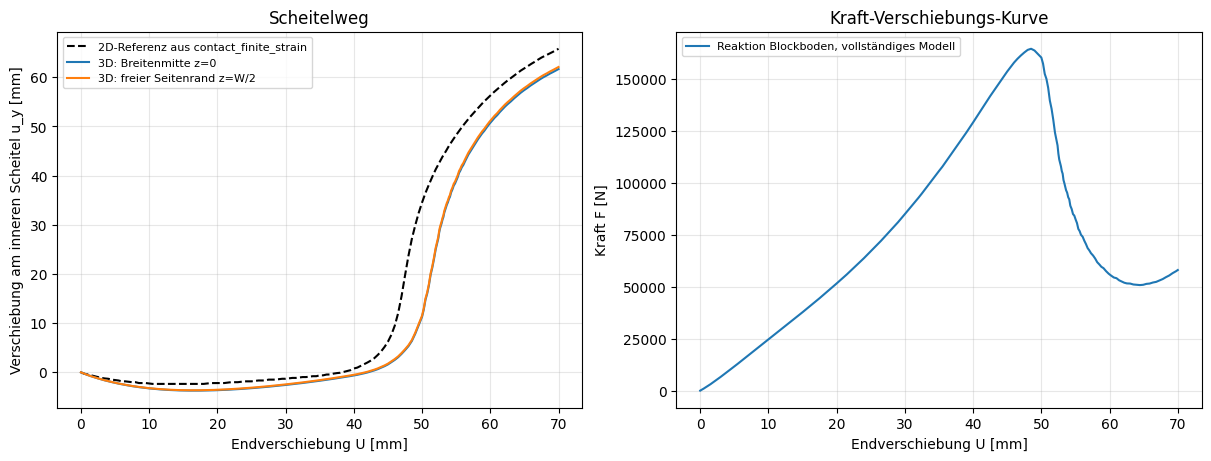

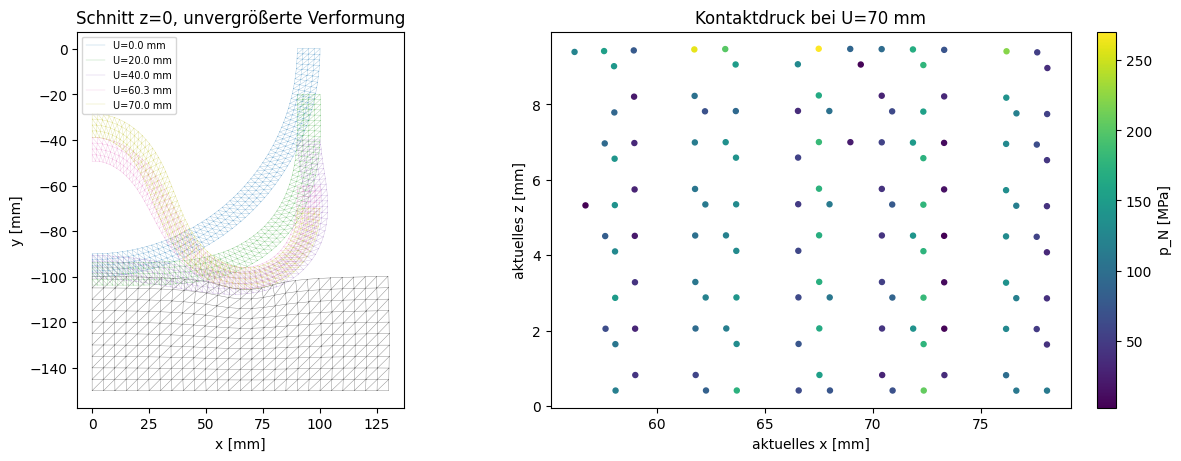

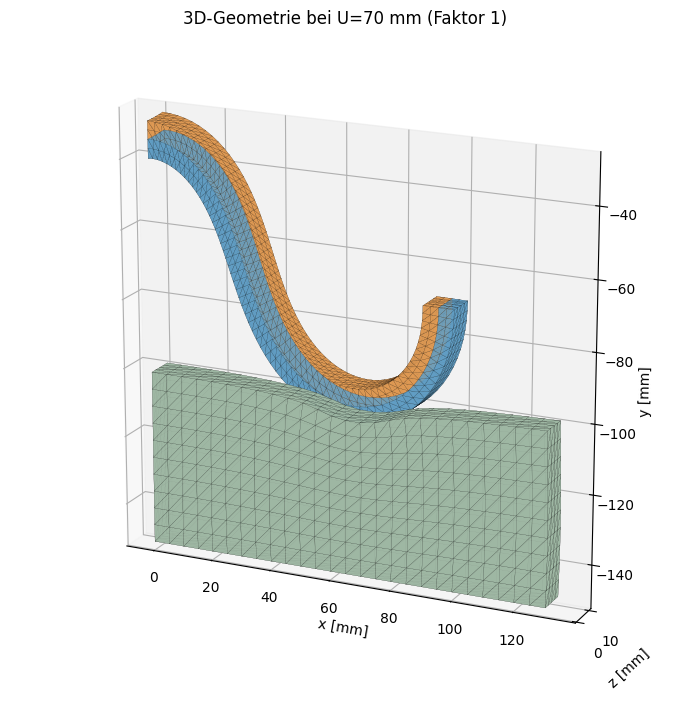

In [10]:
ref_data = np.array([
    [0.0, 0.000],
    [0.5, -0.291],
    [1.0, -0.438],
    [1.5, -0.613],
    [2.0, -0.787],
    [2.5, -0.961],
    [3.0, -1.135],
    [3.5, -1.244],
    [4.0, -1.309],
    [4.5, -1.483],
    [5.0, -1.571],
    [5.5, -1.658],
    [6.0, -1.832],
    [6.5, -1.832],
    [7.0, -1.919],
    [7.5, -2.006],
    [8.0, -2.006],
    [8.5, -2.180],
    [9.0, -2.180],
    [9.5, -2.180],
    [10.0, -2.265],
    [10.5, -2.354],
    [11.0, -2.354],
    [11.5, -2.354],
    [12.0, -2.354],
    [12.5, -2.354],
    [13.0, -2.354],
    [13.5, -2.354],
    [14.0, -2.354],
    [14.5, -2.354],
    [15.0, -2.354],
    [15.5, -2.354],
    [16.0, -2.354],
    [16.5, -2.354],
    [17.0, -2.354],
    [17.5, -2.354],
    [18.0, -2.354],
    [18.5, -2.267],
    [19.0, -2.188],
    [19.5, -2.180],
    [20.0, -2.180],
    [20.5, -2.180],
    [21.0, -2.180],
    [21.5, -2.093],
    [22.0, -2.006],
    [22.5, -2.006],
    [23.0, -2.006],
    [23.5, -1.919],
    [24.0, -1.832],
    [24.5, -1.832],
    [25.0, -1.832],
    [25.5, -1.745],
    [26.0, -1.658],
    [26.5, -1.658],
    [27.0, -1.658],
    [27.5, -1.483],
    [28.0, -1.483],
    [28.5, -1.483],
    [29.0, -1.396],
    [29.5, -1.309],
    [30.0, -1.309],
    [30.5, -1.222],
    [31.0, -1.135],
    [31.5, -1.135],
    [32.0, -1.048],
    [32.5, -0.961],
    [33.0, -0.961],
    [33.5, -0.874],
    [34.0, -0.787],
    [34.5, -0.787],
    [35.0, -0.613],
    [35.5, -0.613],
    [36.0, -0.449],
    [36.5, -0.438],
    [37.0, -0.264],
    [37.5, -0.160],
    [38.0, -0.090],
    [38.5, 0.084],
    [39.0, 0.258],
    [39.5, 0.432],
    [40.0, 0.781],
    [40.5, 0.955],
    [41.0, 1.303],
    [41.5, 1.628],
    [42.0, 2.000],
    [42.5, 2.401],
    [43.0, 2.879],
    [43.5, 3.523],
    [44.0, 4.258],
    [44.5, 5.167],
    [45.0, 6.234],
    [45.5, 7.638],
    [46.0, 9.495],
    [46.5, 12.071],
    [47.0, 15.535],
    [47.5, 19.683],
    [48.0, 23.658],
    [48.5, 27.119],
    [49.0, 29.894],
    [49.5, 32.399],
    [50.0, 34.537],
    [50.5, 36.480],
    [51.0, 38.155],
    [51.5, 39.758],
    [52.0, 41.269],
    [52.5, 42.565],
    [53.0, 43.860],
    [53.5, 44.982],
    [54.0, 46.191],
    [54.5, 47.226],
    [55.0, 48.260],
    [55.5, 49.208],
    [56.0, 50.155],
    [56.5, 51.021],
    [57.0, 51.876],
    [57.5, 52.665],
    [58.0, 53.423],
    [58.5, 54.196],
    [59.0, 54.945],
    [59.5, 55.605],
    [60.0, 56.253],
    [60.5, 56.941],
    [61.0, 57.549],
    [61.5, 58.140],
    [62.0, 58.739],
    [62.5, 59.299],
    [63.0, 59.821],
    [63.5, 60.343],
    [64.0, 60.866],
    [64.5, 61.386],
    [65.0, 61.811],
    [65.5, 62.259],
    [66.0, 62.722],
    [66.5, 63.130],
    [67.0, 63.582],
    [67.5, 64.001],
    [68.0, 64.349],
    [68.5, 64.698],
    [69.0, 65.046],
    [69.5, 65.394],
    [70.0, 65.794]
])


fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
axes[0].plot(ref_data[:, 0], ref_data[:, 1], "k--", label="2D-Referenz aus contact_finite_strain")
axes[0].plot(load_history[:, 0], load_history[:, 1], label="3D: Breitenmitte z=0")
axes[0].plot(load_history[:, 0], load_history[:, 2], label="3D: freier Seitenrand z=W/2")
axes[0].set(xlabel="Endverschiebung U [mm]", ylabel="Verschiebung am inneren Scheitel u_y [mm]",
            title="Scheitelweg")
axes[1].plot(load_history[:, 0], load_history[:, 3], label="Reaktion Blockboden, vollständiges Modell")
axes[1].set(xlabel="Endverschiebung U [mm]", ylabel="Kraft F [N]", title="Kraft-Verschiebungs-Kurve")
for ax in axes:
    ax.grid(alpha=.3)
    ax.legend(fontsize=8)
fig.savefig(results / "load_displacement.png", dpi=180)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
symmetry_facets = facet_tags.find(SYM_Z)
symmetry_nodes, symmetry_cells = boundary_triangles(symmetry_facets)
arch_symmetry = symmetry_nodes[cell_tags.values[symmetry_cells] != BODY_3]
base_symmetry = symmetry_nodes[cell_tags.values[symmetry_cells] == BODY_3]
for load, positions in snapshots:
    axes[0].triplot(positions[:, 0], positions[:, 1], arch_symmetry, lw=.25, alpha=.5,
                    label=f"U={load:.1f} mm")
axes[0].triplot(x_current[:, 0], x_current[:, 1], base_symmetry, color="grey", lw=.3)
axes[0].set(xlabel="x [mm]", ylabel="y [mm]", aspect="equal", title="Schnitt z=0, unvergrößerte Verformung")
axes[0].legend(fontsize=7)
active_plot = contact_data[:, 4] > 0
sc = axes[1].scatter(contact_data[active_plot, 0], contact_data[active_plot, 2],
                     c=contact_data[active_plot, 4], s=13, cmap="viridis")
axes[1].set(xlabel="aktuelles x [mm]", ylabel="aktuelles z [mm]", title="Kontaktdruck bei U=70 mm")
fig.colorbar(sc, ax=axes[1], label="p_N [MPa]")
fig.savefig(results / "contact_and_section.png", dpi=180)
plt.show()

fig = plt.figure(figsize=(9, 7), constrained_layout=True)
ax = fig.add_subplot(111, projection="3d")
all_boundary_nodes, all_boundary_cells = boundary_triangles(exterior)
colors = {BODY_1: "#5e9cc3", BODY_2: "#df9850", BODY_3: "#9db6a2"}
for tag in (BODY_1, BODY_2, BODY_3):
    selected = all_boundary_nodes[cell_tags.values[all_boundary_cells] == tag]
    surface = Poly3DCollection(x_current[selected][:, :, [0, 2, 1]], facecolor=colors[tag], edgecolor="k", linewidth=.08, alpha=.85)
    ax.add_collection3d(surface)
# Für die Darstellung ist y vertikal: Achsenreihenfolge (x, z, y).
plot_coordinates = x_current[:, [0, 2, 1]]
ax.auto_scale_xyz(*plot_coordinates.T)
ax.set_yticks([0, half_width])
ax.set_box_aspect(np.ptp(plot_coordinates, axis=0))
ax.view_init(elev=18, azim=-65)
ax.set(xlabel="x [mm]", ylabel="z [mm]", zlabel="y [mm]", title="3D-Geometrie bei U=70 mm (Faktor 1)")
fig.savefig(results / "deformation_3d.png", dpi=180)
plt.show()

Die Netzdichte kann über `n_angle`, `n_layer`, `n_width`, `n_block_x` und
`n_block_y` verändert werden. Bei T4 beeinflusst insbesondere die Auflösung
über der Schichtdicke die Biegesteifigkeit. Die sichtbare Abweichung von der
2D-Kurve enthält sowohl diese Diskretisierungseffekte als auch die geänderten
dreidimensionalen Randbedingungen; sie ist kein isolierter Kontaktfehler.

Die lokale Tangentenprüfung umfasst Flächen-, Kanten- und Eckprojektionen
unter endlicher Rotation und Verzerrung. Die globale Prüfung erfolgt am
vollständig verformten Endzustand. Zu jedem akzeptierten Lastzustand werden
Kraftresiduum, Kräftebilanz und die kleinste Jacobi-Determinante geprüft.